# Hands-on Sesi 7

> Topik: Supervised Learning - Regresi Linear, Evaluasi Model, Residual Plot

Nama Lengkap : Rexxy Andrew Gunawan

NIM          : 240401010223

Kelas        : IF403

Program Studi: S1 PJJ Informatika UNSIA

Mata Kuliah  : Data Science

Disusun oleh : Rexxy Andrew Gunawan

Link Google Colab: https://colab.research.google.com/drive/1K0UIYBa8l8IY3mxSw1dl3p39w5PEEQ1T?usp=sharing

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# 1. Generate & Eksplorasi Dataset

In [ ]:
# Generate dataset sintetis untuk prediksi gaji
np.random.seed(42)
n = 300

pengalaman = np.random.randint(0, 21, n)
edu = np.random.choice(['SMA', 'D3', 'S1', 'S2'], n, p=[0.25, 0.25, 0.35, 0.15])
kota = np.random.choice(['Jakarta', 'Bandung', 'Surabaya'], n, p=[0.45, 0.30, 0.25])

bonus_edu = {'SMA': 0, 'D3': 500_000, 'S1': 1_200_000, 'S2': 2_000_000}
bonus_kota = {'Jakarta': 1_000_000, 'Bandung': 400_000, 'Surabaya': 300_000}

noise = np.random.normal(0, 500_000, n)
gaji = (3_000_000 + 750_000 * pengalaman
        + np.vectorize(bonus_edu.get)(edu)
        + np.vectorize(bonus_kota.get)(kota)
        + noise)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print('Dataset sintetis prediksi gaji berhasil dibuat:')
print(df.head())

In [ ]:
# EDA singkat
print('Shape:', df.shape, '\n')
print(df.info())
print(df.describe(include='all').transpose())

Shape: (300, 4) 

       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


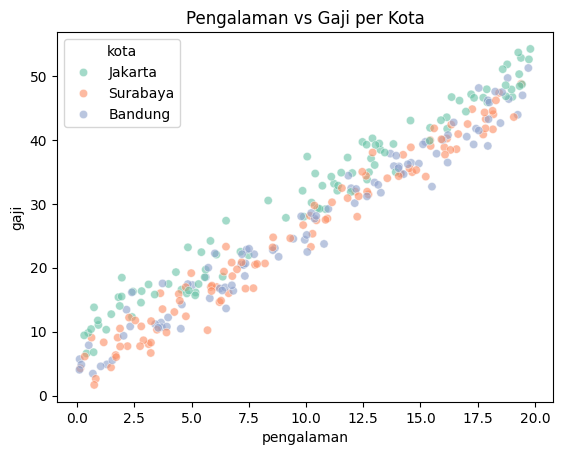

In [ ]:
# Scatter: pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='edu', palette='viridis', alpha=0.7)
plt.title('Hubungan Pengalaman Kerja dan Gaji')
plt.xlabel('Pengalaman (tahun)')
plt.ylabel('Gaji (rupiah)')
plt.show()

# 2. Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# One-Hot Encoding kolom kategorikal
df = pd.get_dummies(df, columns=['edu', 'kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


# 3. Latih Model & Tampilkan Koefisien

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'Intercept: {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

# Interpretasi: fitur dengan koefisien positif cenderung menaikkan gaji

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


# 4. Evaluasi Model

In [ ]:
from sklearn.metrics import (mean_absolute_error,
    root_mean_squared_error, r2_score)

In [ ]:
y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = Rp {mae:,.0f}')
print(f'RMSE = Rp {rmse:,.0f}')
print(f'R2   = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740  (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


# 5. Visualisasi & Interpretasi

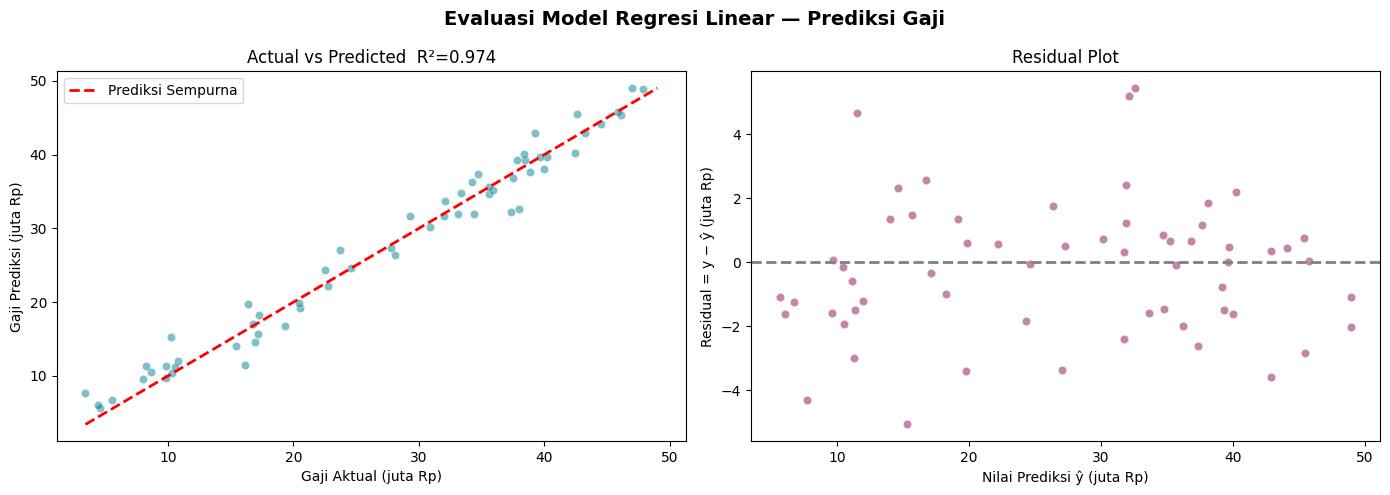

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (rupiah)')
axes[0].set_ylabel('Gaji Prediksi (rupiah)')
axes[0].set_title(f'Actual vs Predicted  R2={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi y-hat (rupiah)')
axes[1].set_ylabel('Residual = y - y-hat (rupiah)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear - Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

Plot Actual vs Predicted

* Sebagian besar titik berada dekat garis referensi 45 derajat, menunjukkan prediksi model cukup akurat terhadap nilai aktual.
* Tidak terlihat penyimpangan besar yang konsisten pada rentang gaji tertentu, sehingga error model relatif stabil.
* Temuan ini selaras dengan nilai R2 yang tinggi, artinya model mampu menjelaskan mayoritas variasi gaji pada data uji.

Residual Plot

* Residual tersebar di sekitar garis nol dengan pola yang cenderung acak.
* Tidak tampak pola melengkung atau bentuk corong yang kuat, sehingga asumsi linearitas masih cukup terpenuhi untuk baseline model.
* Hasil ini mendukung bahwa regresi linear layak digunakan sebagai model awal untuk kasus prediksi gaji sintetis.

# Kesimpulan Sesi Pembelajaran Sesi 7

* Apa yang telah dipelajari: Saya telah mempraktikkan alur supervised learning untuk regresi linear, mulai dari pembuatan dataset sintetis prediksi gaji, preprocessing (encoding dan scaling), pelatihan model, hingga evaluasi metrik dan residual plot.

* Temuan utama: Model regresi linear mencapai nilai R2 tinggi, yang menunjukkan sebagian besar variasi gaji dapat dijelaskan oleh fitur seperti pengalaman, pendidikan, dan kota. Residual plot juga menunjukkan sebaran error yang relatif acak di sekitar nol.

* Keterbatasan atau pertanyaan: Dataset yang digunakan masih sintetis sehingga cenderung lebih terstruktur dibanding data riil. Tahap lanjutan yang menarik adalah menguji model pada data gaji nyata, melakukan validasi silang, dan membandingkan dengan model regresi lain.